In [2]:
!pip install io

ERROR: Could not find a version that satisfies the requirement io (from versions: none)
ERROR: No matching distribution found for io


In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,Flatten,BatchNormalization,MaxPooling2D,Flatten,Input,Dropout
from tensorflow.keras.regularizers import L2

In [2]:
dataset=keras.preprocessing.image_dataset_from_directory(
    directory='dataset',
    batch_size=32,
    image_size=(256,256),
    shuffle=True,
    label_mode='int'
)

Found 2152 files belonging to 3 classes.


In [3]:
len(dataset)

68

In [4]:
print(68*32)

2176


## Visualization

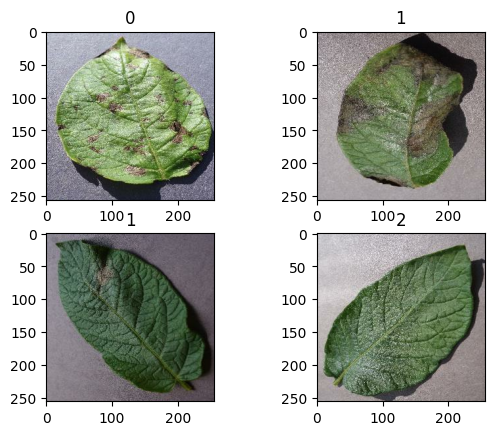

In [5]:
for image_batch,label_batch in dataset.take(1):
    for i in range(4):
        plt.subplot(2,2,i+1)
        plt.imshow(image_batch[i].numpy().astype('uint8'))
        plt.title(label_batch[i].numpy().astype('int32'))
     

## Splitting the dataset

In [6]:
train_size=0.8
validation_size=0.1
test_size=0.1

In [7]:
def dataset_splitter(df):
    dataset_length=len(dataset)
    training_size=int(68*0.8)
    train_data=dataset.take(training_size)
    remaining_data=dataset.skip(54)
    validation_data=remaining_data.take(6)
    test_data=remaining_data.skip(6)
    return train_data,validation_data,test_data

In [8]:
train_data,validation_data,test_data=dataset_splitter(dataset)

In [9]:
print(len(validation_data))

6


In [10]:
print(len(test_data))

8


### Data Augmentation

In [11]:
from tensorflow.keras import layers

In [12]:
Data_Augmentation=tf.keras.Sequential([
      layers.RandomFlip("horizontal_and_vertical"),
      layers.RandomRotation(0.2),
      layers.RandomZoom(0.1),
])

### Rescalling and Resizing in CNN

In [13]:
Scaling_and_Resizing=tf.keras.Sequential([
    layers.Resizing(256,256),
    layers.Rescaling(1./255)
])

### CNN Model

In [16]:
model=Sequential([
    Input(shape=(256, 256, 3)),
    Scaling_and_Resizing,
    Data_Augmentation,
    
    Conv2D(32,kernel_size=(3,3),padding='same',activation='relu'),
    MaxPooling2D(pool_size=(2,2),padding='valid',strides=(2,2)),
    BatchNormalization(),
    Dropout(0.3),
    
    Conv2D(64,kernel_size=(3,3),padding='same',activation='relu'),
    MaxPooling2D(pool_size=(2,2),padding='valid',strides=(2,2)),
    BatchNormalization(),
    Dropout(0.4),
    
    Conv2D(64,kernel_size=(3,3),padding='same',activation='relu'),
    MaxPooling2D(pool_size=(2,2),padding='valid',strides=(2,2)),
    BatchNormalization(),
    Dropout(0.4),

    Conv2D(32,padding='valid',kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2),strides=(2,2),padding='same'),
    BatchNormalization(),
    Dropout(0.3),

    Flatten(),
    Dense(32,activation='relu',kernel_regularizer=L2(0.01)),
    Dropout(0.3),
    Dense(3,activation='softmax')
])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)            │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 256, 256, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 128, 128, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 30, 30, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 15, 15, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 7200)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 306,083 (1.17 MB)

 Trainable params: 305,699 (1.17 MB)

 Non-trainable params: 384 (1.50 KB)

In [19]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(0.001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [18]:
history=model.fit(train_data,epochs=50,validation_data=validation_data,batch_size=32)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8709 - loss: 1.0518 - val_accuracy: 0.4635 - val_loss: 4.7071
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.9225 - loss: 0.7999 - val_accuracy: 0.4740 - val_loss: 5.9136
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.9352 - loss: 0.6794 - val_accuracy: 0.4688 - val_loss: 7.4306
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.9387 - loss: 0.6025 - val_accuracy: 0.4792 - val_loss: 6.9291
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.9294 - loss: 0.5747 - val_accuracy: 0.4531 - val_loss: 3.5925
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.9363 - loss: 0.5011 - val_accuracy: 0.4531 - val_loss: 6.4323
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.9473 - loss: 0.4551 - val_accuracy: 0.4323 - val_loss: 2.6958
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9416 - loss: 0.4186 - val_accuracy: 0.7760 - v

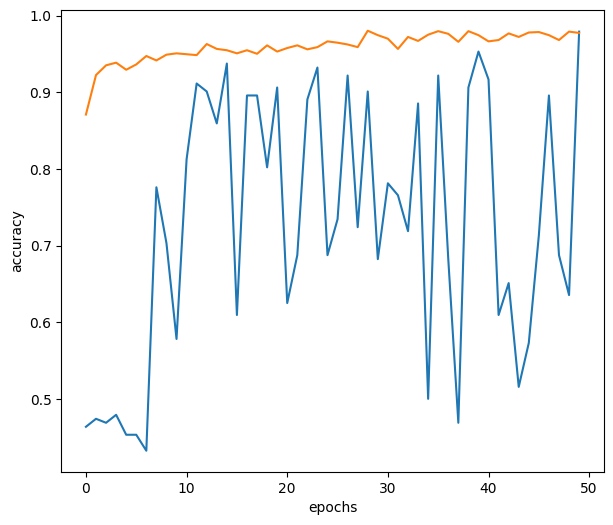

In [20]:
plt.figure(figsize=(7,6))
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.plot(history.history['accuracy'],label='accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.show()

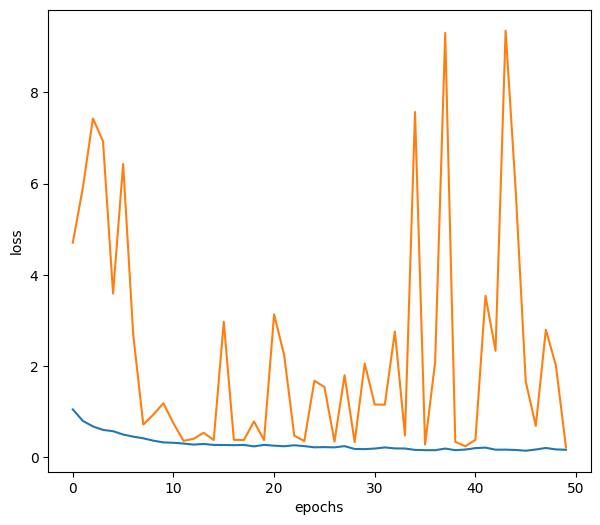

In [21]:
plt.figure(figsize=(7,6))
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

In [23]:
model.evaluate(test_data)

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 316ms/step - accuracy: 0.9698 - loss: 0.2024


[0.20243822038173676, 0.9698275923728943]

In [24]:
model.save('model.keras')